# How well do jobs and skills pay for Data Analysts?

### Methodology

1. Median Salary for top 6 Data Jobs
2. Find median salary per skill for Data Analysts
3. Highest paying and most demanded skills.



In [7]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  

df = pd.read_csv('C:/Users/jhonn/Downloads/data_jobs.csv')

#Cleaning the date 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [8]:
df_usa = df[df['job_country']=='United States'].dropna(subset=['salary_year_avg']).copy()

In [9]:
job_titles = df_usa['job_title_short'].value_counts().index[:6].tolist()

In [12]:
df_us_6 = df_usa[df_usa['job_title_short'].isin(job_titles)]
df_us_6.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
92,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,"Illinois, United States",2023-02-21 13:29:59,False,True,United States,year,120000.0,NaN,Apex Systems,"[sql, python]","{'programming': ['sql', 'python']}"
100,Data Scientist,"Data Scientist, Risk Data Mining - USDS","Mountain View, CA",via LinkedIn,Full-time,False,"California, United States",2023-07-31 13:01:18,False,True,United States,year,228222.0,NaN,TikTok,"[sql, r, python, express]","{'programming': ['sql', 'r', 'python'], 'webfr..."
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,"[python, r, alteryx, tableau]","{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
116,Data Scientist,Data Scientist,Anywhere,via LinkedIn,Full-time,True,"Texas, United States",2023-10-04 13:04:23,False,False,United States,year,114000.0,NaN,4 Corner Resources,"[r, python, sql, t-sql, hadoop, spark, tableau]","{'analyst_tools': ['tableau'], 'libraries': ['..."
146,Data Engineer,Data Engineer Graduate (Real Time Communicatio...,"Seattle, WA",via LinkedIn,Full-time,False,"California, United States",2023-10-21 13:06:16,False,True,United States,year,129500.0,NaN,ByteDance,"[golang, scala, python, java, hadoop, spark]","{'libraries': ['hadoop', 'spark'], 'programmin..."


In [20]:
joborder = df_us_6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending = False).index

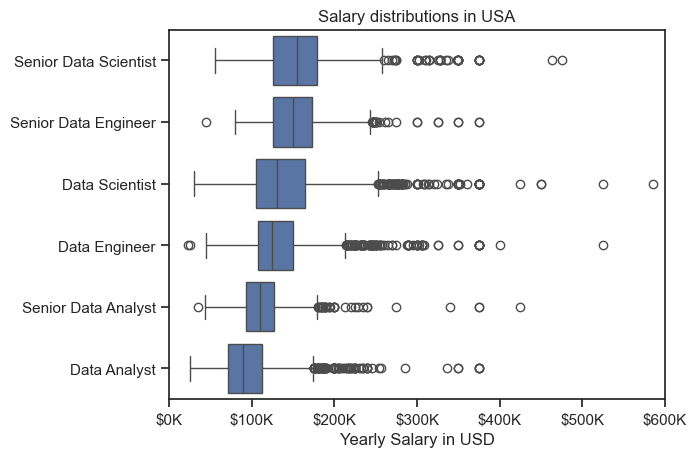

In [21]:
sns.boxplot(data=df_us_6, x='salary_year_avg', y='job_title_short', order= joborder)
sns.set_theme(style='ticks')
plt.title('Salary distributions in USA')
plt.xlabel('Yearly Salary in USD')
plt.ylabel('')
plt.xlim(0, 600000)
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()



In [23]:
# Investigate Median Salary vs Skill for Data Analysts

df_usa_da = df[(df['job_country']=='United States')&(df['job_title_short']=='Data Analyst')].copy()

In [24]:
df_usa_da = df_usa_da.dropna(subset=['salary_year_avg'])

In [25]:
df_usa_da = df_usa_da.explode('job_skills')
df_usa_da[['salary_year_avg','job_skills']].head()

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [ ]:
df_da_toppay = df_usa_da.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending = False)
df_da_toppay = df_da_toppay.head(10)

pandas.core.frame.DataFrame

In [35]:

df_da_skills = df_usa_da.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending = False)
df_da_skills = df_da_skills.head(10)

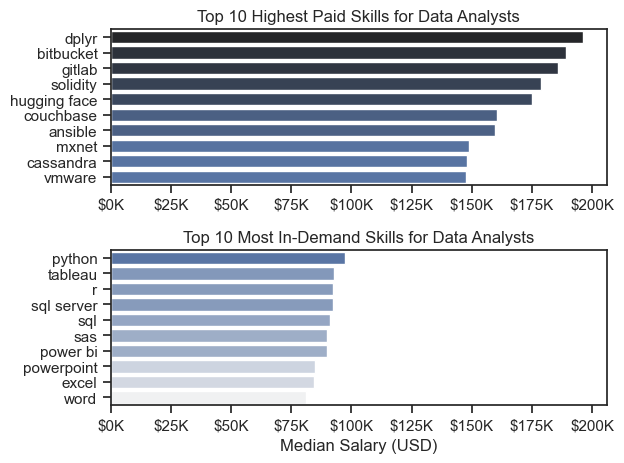

In [42]:
fig, ax = plt.subplots(2,1)

sns.set_theme(style="ticks")

# Top 10 Highest Paid Skills for Data Analysts

sns.barplot(data= df_da_toppay, x = 'median', y = df_da_toppay.index, ax=ax[0], hue = 'median', palette = 'dark:b_r' )
ax[0].legend().remove()
# df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False) 
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


# Top 10 Most In-Demand Skills for Data Analysts

# Sort from largest to smallest
df_da_skills = df_da_skills.sort_values(by='median', ascending=False)

# Plot
sns.barplot(
    data=df_da_skills,
    x='median',
    y=df_da_skills.index,
    ax=ax[1],
    hue='median',
    palette='light:b',
)
ax[1].legend().remove()
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K')
)

plt.tight_layout()
plt.show()
